미국 매사추세츠주 네이틱(Natick, MA)에 위치한 MathWorks 본사 주차장 서쪽(West Garage)


field1 : Wind Direction (풍향) - 도(Degree) 단위 (0~360도)

field2 : Wind Speed (풍속) - mph 또는 m/s 단위

field3 : Humidity (상대 습도) - 퍼센트(%) 단위 (0~100%)

field4 : Temperature (기온) - 화씨(°F) 단위 

field5 : Rain (강우량) - 인치 또는 mm 단위

field6 : Pressure (기압) - hPa 또는 inHg 단위

field7 : Light Intensity (조도/일사량) - 빛의 세기

field8 : Battery Value (센서 배터리 전압) - 장비 전원 상태 (V)

In [19]:
import requests
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import platform

# ==========================================
# 0. 한글 폰트 및 환경 세팅
# ==========================================
if platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': # Windows
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 

# ==========================================
# 1. 데이터 수집 (ThingSpeak API)
# ==========================================
print("1단계: 실시간 IoT 센서 데이터 수집 중...")
url = "https://api.thingspeak.com/channels/12397/feeds.json?results=500"
response = requests.get(url)
data = response.json()
data

1단계: 실시간 IoT 센서 데이터 수집 중...


{'channel': {'id': 12397,
  'name': 'WeatherStation',
  'description': 'MathWorks Weather Station, West Garage, Natick, MA 01760, USA',
  'latitude': '42.299676',
  'longitude': '-71.350525',
  'field1': 'Wind Direction (North = 0 degrees)',
  'field2': 'Wind Speed (mph)',
  'field3': '% Humidity',
  'field4': 'Temperature (F)',
  'field5': 'Rain (Inches/minute)',
  'field6': 'Pressure ("Hg)',
  'field7': 'Power Level (V)',
  'field8': 'Light Intensity',
  'created_at': '2014-05-20T21:50:32Z',
  'updated_at': '2025-10-02T21:56:57Z',
  'elevation': '60',
  'last_entry_id': 5605125},
 'feeds': [{'created_at': '2026-05-26T04:55:38Z',
   'entry_id': 5604626,
   'field1': '139',
   'field2': '0.1',
   'field3': '0',
   'field4': '0.1',
   'field5': '0',
   'field6': '29.85',
   'field7': '0',
   'field8': '0'},
  {'created_at': '2026-05-26T04:56:38Z',
   'entry_id': 5604627,
   'field1': '185',
   'field2': '0.5',
   'field3': '0',
   'field4': '0.1',
   'field5': '0',
   'field6': '29.85',

In [20]:
df = pd.DataFrame(data['feeds']).dropna()
df = df[['created_at', 'field1']].dropna()
df.columns = ['Time', 'Value']
df['Value'] = pd.to_numeric(df['Value'])

In [21]:
df

,Time,Value
0,2026-05-26T04:55:38Z,139
1,2026-05-26T04:56:38Z,185
2,2026-05-26T04:57:38Z,68
3,2026-05-26T04:58:38Z,178
4,2026-05-26T04:59:38Z,180
...,...,...
495,2026-05-26T13:31:38Z,128
496,2026-05-26T13:32:38Z,149
497,2026-05-26T13:33:38Z,172
498,2026-05-26T13:34:38Z,144


In [24]:

# ==========================================
# 2. 데이터 전처리 및 커스텀 Dataset 정의
# ==========================================
print("2단계: 데이터 정규화 및 PyTorch Dataset 구성 중...")
scaler = MinMaxScaler()
df['Scaled_Value'] = scaler.fit_transform(df[['Value']])
features = df[['Scaled_Value']].values

# 강사님이 앞서 작성하신 커스텀 윈도우 데이터셋 클래스 구조 적용
class WindowDS(Dataset):
    def __init__(self, _data, _window):
        self.data = _data
        self.window = _window
        self.n = len(_data) - _window

    def __len__(self):
        return max(self.n, 1)

    def __getitem__(self, idx):
        # 입력 데이터 (과거 window만큼의 데이터 추출)
        x_window = self.data[idx : idx + self.window]
        # 타깃 데이터 (바로 다음 시점의 정답 데이터)
        y_next = self.data[idx + self.window]
        
        # 메모리 효율을 위해 from_numpy 사용 후 차원 정렬 (float 타입 변환)
        # LSTM 입력 규격: (Sequence, Feature) -> 여기서는 Feature가 1개이므로 reshape(-1, 1)
        x_tensor = torch.from_numpy(x_window).float()
        y_tensor = torch.tensor(y_next).float() # 1차원 텐서로 변환
        
        return x_tensor, y_tensor

window = 10
sensor_dataset = WindowDS(features, window)

# 데이터 가부하를 방지하기 위한 DataLoader 적재 (Batch Size: 32)
train_loader = DataLoader(sensor_dataset, batch_size=32, shuffle=False)


2단계: 데이터 정규화 및 PyTorch Dataset 구성 중...


In [29]:

# ==========================================
# 3. LSTM 모델 아키텍처 정의
# ==========================================
class SensorLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1):
        super(SensorLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (Batch, Sequence, Feature)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # 마지막 시점(-1)의 출력 벡터를 선형 레이어로 전달
        prediction = self.fc(h_n[-1])
        return prediction

model = SensorLSTM()

# ==========================================
# 4. 모델 학습 루프 (Training Loop)
# ==========================================
print("3단계: LSTM 모델 학습 진행 중 (총 30 에포크)...")
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

model.train()
for epoch in range(30):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()               # 1. 오답노트 초기화
        predictions = model(X_batch)        # 2. 문제 풀기 (예측)
        loss = criterion(predictions, y_batch) # 3. 채점하기 (오차 계산)
        loss.backward()                     # 4. 원인 분석 (역전파)
        optimizer.step()                    # 5. 실력 향상 (가중치 수정)
        
        total_loss += loss.item()
        
    if (epoch + 1) % 10 == 0:
        print(f"   Epoch [{epoch+1}/30] -> 평균 오차(Loss): {total_loss/len(train_loader):.4f}")


3단계: LSTM 모델 학습 진행 중 (총 30 에포크)...
   Epoch [10/30] -> 평균 오차(Loss): 0.0594
   Epoch [20/30] -> 평균 오차(Loss): 0.0579
   Epoch [30/30] -> 평균 오차(Loss): 0.0572


In [38]:

# ==========================================
# 5. 전체 데이터 추론 및 이상 감지 (Anomaly Detection)
# ==========================================
print("4단계: 학습 완료된 모델 기반 이상 징후 추론 중...")
model.eval()

# 시각화를 위해 전체 데이터를 한 번에 담아서 예측 (추론 단계이므로 DataLoader 없이 진행)
# 실제 전반적인 연산을 위해 Dataset의 전체 데이터를 배치 형태로 병합합니다.
full_loader = DataLoader(sensor_dataset, batch_size=len(sensor_dataset), shuffle=False)
# next(iter(full_loader))
# X_all, y_all = next(iter(full_loader))
for x_all, y_all in full_loader:
    break

with torch.no_grad():
    all_predictions = model(X_all)
    # 각 데이터 샘플별 오차 계산
    errors = torch.abs(y_all - all_predictions).numpy()

# 오차 분포의 상위 5% 지점을 이상치 임계값(Threshold)으로 설정
threshold = np.percentile(errors, 95)
anomalies = errors > threshold
print(f"   [설정 완료] 이상 감지 임계값: {threshold:.4f}")


4단계: 학습 완료된 모델 기반 이상 징후 추론 중...
   [설정 완료] 이상 감지 임계값: 0.5479


5단계: 시각화 그래프 생성 중...


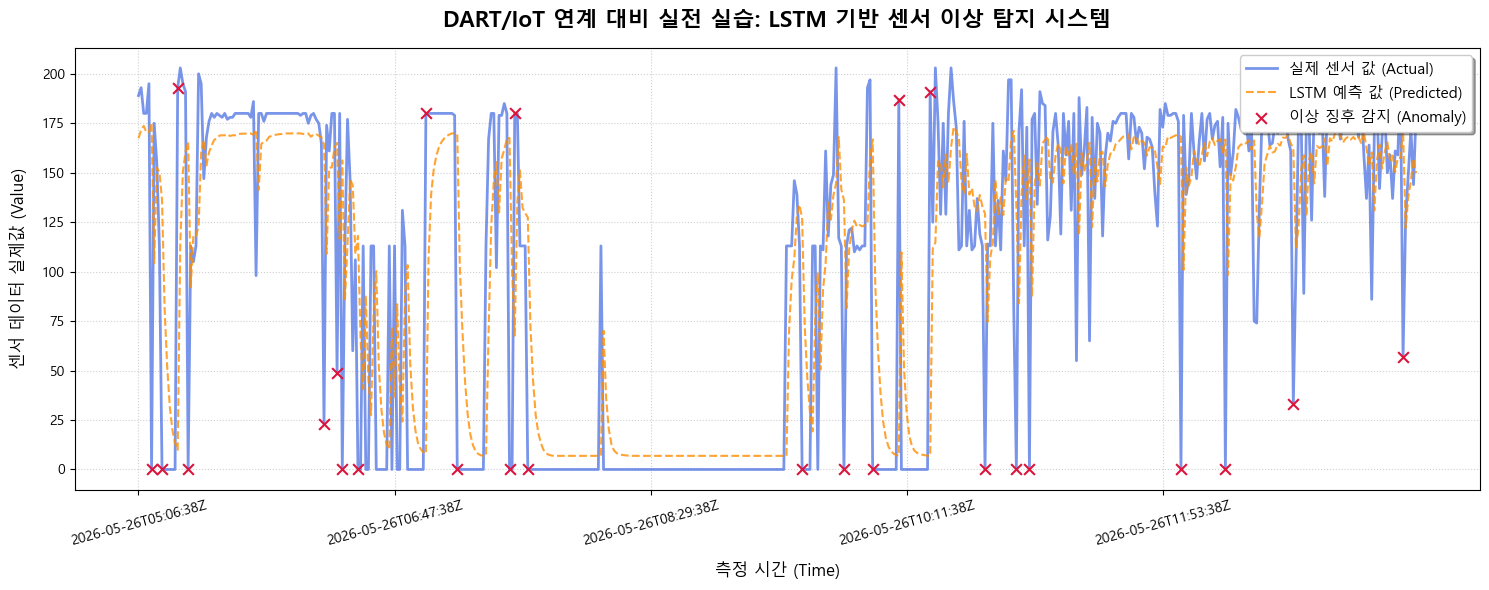

모든 프로세스가 성공적으로 완료되었습니다!


In [41]:

# ==========================================
# 6. 결과 역전파(Inverse) 및 시각화 (Matplotlib)
# ==========================================
print("5단계: 시각화 그래프 생성 중...")

# 0~1 값을 원래 센서 단위(예: 실제 온도)로 복원
actual_y = scaler.inverse_transform(y_all.numpy())
predicted_y = scaler.inverse_transform(all_predictions.numpy())
plot_time = df['Time'].iloc[window:].values

plt.figure(figsize=(15, 6))

# 실제값과 예측값 선 그래프
plt.plot(plot_time, actual_y, label='실제 센서 값 (Actual)', color='royalblue', alpha=0.7, linewidth=2)
plt.plot(plot_time, predicted_y, label='LSTM 예측 값 (Predicted)', color='darkorange', linestyle='--', alpha=0.8)

# 이상치가 감지된 인덱스 추출 후 산점도(Scatter) 표시
anomaly_indices = np.where(anomalies)[0]
if len(anomaly_indices) > 0:
    plt.scatter(plot_time[anomaly_indices], actual_y[anomaly_indices], 
                color='crimson', label='이상 징후 감지 (Anomaly)', 
                s=60, marker='x', zorder=5)

plt.title('DART/IoT 연계 대비 실전 실습: LSTM 기반 센서 이상 탐지 시스템', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('측정 시간 (Time)', fontsize=12, labelpad=10)
plt.ylabel('센서 데이터 실제값 (Value)', fontsize=12, labelpad=10)
plt.xticks(plot_time[::len(plot_time)//5], rotation=15) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)

plt.tight_layout()
plt.show()
print("모든 프로세스가 성공적으로 완료되었습니다!")